## Project 6: Face Detection using Single Face Per Image

In [95]:
#importing the necessary libraries
import os  # Helps us look at folders
import torch  # Our robot’s brainpower
from torch.utils.data import Dataset, DataLoader  # How we feed pictures to the robot
from PIL import Image  # Opens pictures
from torchvision import transforms  # Fixes up pictures
import torch.nn as nn  # Builds the robot’s brain
import torch.optim as optim  # Teaches the robot

In [96]:
class FaceImagesDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        ])
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
        print(f"Found {len(self.images)} images in {image_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt'))
        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        box = torch.zeros(4)
        label = torch.tensor(0, dtype=torch.float32)
        # print(f"Checking {img_name}, Label file: {label_path}")  # Spy on file path
        if os.path.exists(label_path):
            with open(label_path, "r") as file:
                first_line = file.readline().strip()
                # print(f"First line: '{first_line}'")  # Spy on content
                if first_line:
                    parts = first_line.split()
                    # print(f"Parts: {parts}")  # Spy on split
                    label_value = int(parts[0])
                    # print(f"Label value: {label_value}")  # Spy on label
                    if label_value == 0:
                        cx, cy, w, h = map(float, parts[1:])
                        x1 = (cx-w/2)*width
                        y1 = (cy-h/2)*height
                        x2 = (cx+w/2)*width
                        y2 = (cy+h/2)*height
                        box = torch.tensor([x1, y1, x2, y2], dtype=torch.float32)
                        label = torch.tensor(1, dtype=torch.float32)
                        # print(f"Found alpaca! Box: {box}")  # Confirm it worked
        # else:
        #     print(f"No label file found at {label_path}")            
        image = self.transform(image)
        return image, label, box

In [97]:
train_dataset = FaceImagesDataset("one_face_per_image/train/images", "one_face_per_image/train/labels")
val_dataset = FaceImagesDataset("one_face_per_image/valid/images", "one_face_per_image/valid/labels")
test_dataset = FaceImagesDataset("one_face_per_image/test/images", "one_face_per_image/test/labels")

Found 1090 images in one_face_per_image/train/images
Found 245 images in one_face_per_image/valid/images
Found 114 images in one_face_per_image/test/images


In [98]:
print(len(train_dataset))

1090


In [99]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

In [100]:
print(len(train_dataloader))

273


going to create the model of 32->32->64->128->256->512

In [101]:
class FaceDetectorSingleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024*1*1, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
        self.bbox_guesser = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024*1*1, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        features = self.cnn(x)
        # print(features.shape)
        face_or_not = self.classifier(features)
        box = self.bbox_guesser(features)
        return face_or_not, box

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaceDetectorSingleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
cls_loss_fn = nn.BCEWithLogitsLoss()
box_loss_fn = nn.SmoothL1Loss()

In [103]:
print("train images:",len(train_dataset))
print("validation images:",len(val_dataset))

train images: 1090
validation images: 245


In [104]:
for epoch in range(100):
    model.train()
    train_loss = 0
    for i, (images, labels, boxes) in enumerate(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        boxes = boxes.to(device)
        # print(f"Batch {i+1}: Labels = {labels}, Boxes = {boxes[:1]}")  # Spy on data
        optimizer.zero_grad()
        face_or_not, pred_boxes = model(images)
        # print(f"Predictions: face_or_not = {face_or_not.view(-1)[:1]}, pred_boxes = {pred_boxes[:1]}")  # Spy on guesses
        cls_loss = cls_loss_fn(face_or_not.view(-1), labels)
        box_loss = box_loss_fn(pred_boxes, boxes)
        loss = cls_loss + 2* box_loss
        # print(f"Losses: cls_loss = {cls_loss.item()}, box_loss = {box_loss.item()}, total = {loss.item()}")  # Spy on loss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss/len(train_dataloader) if len(train_dataloader) > 0 else 0

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for i, (images, labels, boxes) in enumerate(val_dataloader):
            images = images.to(device)
            labels = labels.to(device)
            boxes = boxes.to(device)
            # print(f"Val Batch {i+1}: Labels = {labels}, Boxes = {boxes[:1]}")  # Spy on val data
            face_or_not, pred_boxes = model(images)
            cls_loss = cls_loss_fn(face_or_not.view(-1), labels)
            box_loss = box_loss_fn(pred_boxes, boxes)
            loss = cls_loss + 2*box_loss
            val_loss += loss.item()
    avg_val_loss = val_loss/len(val_dataloader) if len(val_dataloader) > 0 else 0
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}")

Epoch 1: Train Loss: 53.8015, val_loss: 40.3030
Epoch 2: Train Loss: 45.3493, val_loss: 48.9793
Epoch 3: Train Loss: 44.3797, val_loss: 48.9001
Epoch 4: Train Loss: 45.2974, val_loss: 39.4204
Epoch 5: Train Loss: 42.9922, val_loss: 38.6648
Epoch 6: Train Loss: 42.2591, val_loss: 38.0119
Epoch 7: Train Loss: 41.0631, val_loss: 36.2141
Epoch 8: Train Loss: 41.8591, val_loss: 34.6326
Epoch 9: Train Loss: 41.4929, val_loss: 37.1122
Epoch 10: Train Loss: 41.0927, val_loss: 35.6898
Epoch 11: Train Loss: 41.5650, val_loss: 37.4455
Epoch 12: Train Loss: 40.1736, val_loss: 35.8039
Epoch 13: Train Loss: 40.8497, val_loss: 36.1561
Epoch 14: Train Loss: 40.4001, val_loss: 34.2174
Epoch 15: Train Loss: 40.0315, val_loss: 42.1046
Epoch 16: Train Loss: 40.3495, val_loss: 36.7844
Epoch 17: Train Loss: 39.8352, val_loss: 35.0606
Epoch 18: Train Loss: 39.2434, val_loss: 35.4401
Epoch 19: Train Loss: 39.5923, val_loss: 35.7810
Epoch 20: Train Loss: 39.2519, val_loss: 37.8986
Epoch 21: Train Loss: 39.4105

In [105]:
import matplotlib.pyplot as plt

In [106]:
# testing the model
correct_class = 0
total = 0
test_loss = 0

Batch 1:
True Labels: tensor([1., 1., 1., 1.])
Predicted probabilities: tensor([1., 1., 1., 1.])
Predicted Labels: tensor([1., 1., 1., 1.])
Predicted Boxes: tensor([105.3446,  29.9984, 144.9251,  85.8710])
True Boxes: tensor([114.5000,  39.0000, 142.5000,  94.0000])



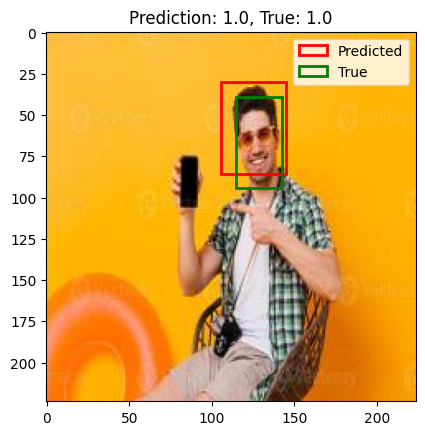

Batch 2:
True Labels: tensor([1., 1., 1., 1.])
Predicted probabilities: tensor([1., 1., 1., 1.])
Predicted Labels: tensor([1., 1., 1., 1.])
Predicted Boxes: tensor([ 70.7033,  33.8869, 156.0505, 159.4650])
True Boxes: tensor([ 62.7500,  33.7500, 157.2500, 180.2500])

Batch 3:
True Labels: tensor([1., 1., 1., 1.])
Predicted probabilities: tensor([1., 1., 1., 1.])
Predicted Labels: tensor([1., 1., 1., 1.])
Predicted Boxes: tensor([ 72.2053,  32.6918, 155.0001, 154.0124])
True Boxes: tensor([ 61.2500,  33.7500, 144.7500, 147.2500])

Batch 4:
True Labels: tensor([1., 1., 1., 1.])
Predicted probabilities: tensor([1., 1., 1., 1.])
Predicted Labels: tensor([1., 1., 1., 1.])
Predicted Boxes: tensor([110.8893,  19.3734, 147.9787,  61.6462])
True Boxes: tensor([ 88.2500,  15.7500, 160.7500,  71.2500])

Batch 5:
True Labels: tensor([1., 1., 1., 1.])
Predicted probabilities: tensor([1., 1., 1., 1.])
Predicted Labels: tensor([1., 1., 1., 1.])
Predicted Boxes: tensor([ 73.9178,  38.2545, 138.0924, 1

In [137]:
with torch.no_grad():
    for i, (images, labels, boxes) in enumerate(test_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        boxes = boxes.to(device)
        face_or_not, pred_boxes = model(images)
        probs = torch.sigmoid(face_or_not.view(-1))
        predictions = (probs > 0.8).float() # 1 if prob > 0.5, else 0
        correct_class += (predictions == labels).sum().item()
        total += labels.size(0)

        # calculate loss
        cls_loss = cls_loss_fn(face_or_not.view(-1), labels)
        box_loss = box_loss_fn(pred_boxes, boxes)
        test_loss += (cls_loss + box_loss).item()

        # print some results
        print(f"Batch {i+1}:")
        print(f"True Labels: {labels}")
        print(f"Predicted probabilities: {probs}")
        print(f"Predicted Labels: {predictions}")
        print(f"Predicted Boxes: {pred_boxes[0]}")
        print(f"True Boxes: {boxes[0]}")
        print()

        #visualize the first image in the first batch
        if i == 0:
            img = images[0].cpu().permute(1, 2, 0)*0.5 + 0.5
            pred_box = pred_boxes[0].cpu().tolist()
            true_box = boxes[0].cpu().tolist()
            plt.imshow(img)
            plt.gca().add_patch(
                plt.Rectangle(
                    (pred_box[0], pred_box[1]), pred_box[2] - pred_box[0], pred_box[3]-pred_box[1], fill=False, edgecolor="red", linewidth=2, label="Predicted"
                )
            )
            plt.gca().add_patch(
                plt.Rectangle(
                    (true_box[0], true_box[1]), true_box[2] - true_box[0], true_box[3] - true_box[1], fill=False, edgecolor="green", linewidth=2, label="True"
                )
            )
            plt.legend()
            plt.title(f"Prediction: {predictions[0].item()}, True: {labels[0].item()}")
            plt.show()

In [80]:
#final results
accuracy = correct_class / total
avg_test_loss = test_loss / len(test_dataloader)
print(f"Test Accuracy: {accuracy:.4f} ({correct_class}/{total})")
print(f"Average Test Loss: {avg_test_loss:.4f}")

Test Accuracy: 1.0000 (1140/1140)
Average Test Loss: 116.1316


In [94]:
# saving the model
torch.save(model.state_dict(), 'single_face_detector_cnn.pth')
print("model saved!!")

model saved!!
